<div style="border: 4px solid #003366; padding: 20px; border-radius: 15px; background-color: #f4f6f7; box-shadow: 5px 5px 10px #888888;">
  <h1 style="text-align: center; color: #003366; font-family: Arial, sans-serif; font-weight: bold;">🎓 TRABAJO FINAL</h1>
  <h2 style="text-align: center; color: #E65100; font-family: Arial, sans-serif;">Fundamentos de Redes Neuronales R y Python</h2>
  <hr style="border: 1px solid #003366;">
  <div style="padding-left: 20px;">
    <h3 style="color: #333;">👥 Integrantes:</h3>
    <ul style="list-style-type: none; font-size: 18px; font-family: monospace; color: #000;">
      <li>🔹 <b>Estela Ramos, Christian Gean Pier</b></li>
      <li>🔹 <b>Zuñe Cordova, Vivian Melissa</b></li>
    </ul>
  </div>
</div>

<div style="border-left: 5px solid #34495E; padding: 10px; background-color: #EBEDEF;">
  <h3 style="color: #2E4053; margin: 0;">🔌 Configuración del Entorno</h3>
  <p style="color: #5D6D7E; margin-top: 5px; font-size: 0.9em;">
    Montaje de Google Drive y verificación de librerías base.
  </p>
</div>

In [ ]:
# 1. Importación de librerías para la ejecución del Trabajo Final
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Gráficos para la expocisión ---
import seaborn as sns
import matplotlib.pyplot as plt

# Tema General
sns.set_theme(style="whitegrid", context="talk") # "talk" hace las letras más grandes y legibles para presentaciones

# Paleta de colores corporativa (Azul sobrio y Naranja de contraste)
mis_colores = ["#2C3E50", "#E67E22", "#27AE60", "#C0392B"]
sns.set_palette(mis_colores)

# Ajuste de tamaño de fuente
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']

# Librerías de Machine Learning y Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import FactorAnalysis
from sklearn.cluster import KMeans

# Librerías de Deep Learning (Keras/TensorFlow)
import tensorflow as tf # Corrected alias from 'pd' to 'tf'
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Input, LSTM, Reshape
from tensorflow.keras.regularizers import l1, l2 # Para L1 (Lasso) y L2 (Ridge)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Drive
from google.colab import drive
drive.mount('/content/drive')

# Cargar dataset
try:
    df = pd.read_csv('/content/drive/MyDrive/TRABAJO FINAL 2712/dataset_credit_cards_10000.csv')
    print("Dataset cargado correctamente. Dimensiones:", df.shape)
    # Vista rápida de las variables objetivo (Targets)
    targets = ['y_default_90d', 'y_churn_180d', 'y_fraud_30d', 'y_clv_12m_usd']
    print(df[targets].describe())
except FileNotFoundError:
    print("¡Error! No se encontró el archivo CSV en la ruta especificada. Asegúrate de que la ruta sea correcta y que Google Drive esté montado.")
except Exception as e:
    print(f"Ocurrió un error al cargar el dataset: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset cargado correctamente. Dimensiones: (10000, 152)
       y_default_90d  y_churn_180d   y_fraud_30d  y_clv_12m_usd
count   10000.000000  10000.000000  10000.000000   10000.000000
mean        0.115000      0.119800      0.043600     169.995163
std         0.319038      0.324744      0.204214     175.641448
min         0.000000      0.000000      0.000000    -935.870000
25%         0.000000      0.000000      0.000000      56.945000
50%         0.000000      0.000000      0.000000     142.915000
75%         0.000000      0.000000      0.000000     246.567500
max         1.000000      1.000000      1.000000    2088.820000


<div style="border-left: 5px solid #F39C12; padding: 10px; background-color: #FEF9E7;">
  <h3 style="color: #D35400; margin: 0;">🧠 Ingeniería de Características & Psicometría</h3>
  <p style="color: #9C640C; margin-top: 5px; font-size: 0.9em;">
    <b></b> Tratamiento de datos ausentes (MNAR) y aplicación de <b>Factor Analysis</b> para descubrir constructos latentes (Autocontrol, Impulsividad) a partir de las encuestas.q1
  </p>
</div>

In [ ]:
# --- MANEJO DE VALORES NULOS (MNAR) ---
imputer = SimpleImputer(strategy='median')
df_numeric = df.select_dtypes(include=[np.number])
df_filled = pd.DataFrame(imputer.fit_transform(df_numeric), columns=df_numeric.columns)

# --- FACTOR ANALYSIS (Para la pregún Nro. 1 del caso) ---
# Seleccionamos las columnas de la encuesta (empiezan con sc_, imp_, fl_, cx_) [cite: 236-258]
survey_cols = [col for col in df.columns if 'item' in col]

# Aplicamos Análisis Factorial para encontrar estructuras latentes
fa = FactorAnalysis(n_components=4, rotation='varimax')
factors = fa.fit_transform(df_filled[survey_cols])

# Agregamos los factores al dataset como nuevas variables (Features)
df_filled['Factor_SelfControl'] = factors[:, 0]
df_filled['Factor_Impulsivity'] = factors[:, 1]
df_filled['Factor_FinLiteracy'] = factors[:, 2]
df_filled['Factor_CX'] = factors[:, 3]

print("Factores latentes creados exitosamente.")

Factores latentes creados exitosamente.


<div style="border-left: 5px solid #C0392B; padding: 15px; background-color: #fdedec;">
  <h3 style="color: #922B21; margin: 0;">🚀 Arquitectura Deep Learning & Entrenamiento</h3>
  <p style="color: #641E16; margin-top: 5px; margin-bottom: 10px; font-size: 0.95em;">
    <b> </b> Implementación "End-to-End" del modelo de riesgo. Incluye preprocesamiento, diseño de la red y entrenamiento con <b>Retropropagación</b>.q3
  </p>
  <div style="display: flex; flex-wrap: wrap; gap: 10px;">
    <span style="background-color: #F5B7B1; color: #922B21; padding: 3px 8px; border-radius: 4px; font-size: 0.85em;"><b>StandardScaler</b></span>
    <span style="background-color: #F5B7B1; color: #922B21; padding: 3px 8px; border-radius: 4px; font-size: 0.85em;"><b>L2 (Ridge)</b></span>
    <span style="background-color: #F5B7B1; color: #922B21; padding: 3px 8px; border-radius: 4px; font-size: 0.85em;"><b>Dropout (30%)</b></span>
    <span style="background-color: #F5B7B1; color: #922B21; padding: 3px 8px; border-radius: 4px; font-size: 0.85em;"><b>Adam Optimizer</b></span>
    <span style="background-color: #F5B7B1; color: #922B21; padding: 3px 8px; border-radius: 4px; font-size: 0.85em;"><b>Early Stopping</b></span>
  </div>
</div>

In [ ]:
# --- PREPARACIÓN DE DATOS PARA REDES NEURONALES ---

# Definimos las variables predictoras (X) excluyendo los targets y IDs
X = df_filled.drop(columns=targets + survey_cols + ['customer_id']) # Usamos los factores en vez de los items sueltos
y_default = df_filled['y_default_90d'] # Objetivo: Predecir Default

# Escalado (OBLIGATORIO para Redes Neuronales):
# Ayuda al "Descenso de Gradiente" a converger más rápido.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir en Train y Test (80% entrenamiento, 20% validación)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_default, test_size=0.2, random_state=42)

# --- CONSTRUCCIÓN DEL MODELO DE DEEP LEARNING ---

def construir_modelo_riesgo(input_shape):
    model = Sequential()

    # Capa de Entrada + Primera Capa Oculta
    # L2 (Ridge): Penaliza pesos grandes para evitar Overfitting
    model.add(Dense(64, activation='relu', input_shape=(input_shape,), kernel_regularizer=l2(0.01)))
9
    # Dropout: Apaga el 30% de neuronas aleatoriamente
    model.add(Dropout(0.3))

    # Segunda Capa Oculta
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.01)))
    model.add(Dropout(0.3))

    # Capa de Salida: Sigmoide porque queremos probabilidad entre 0 y 1
    model.add(Dense(1, activation='sigmoid'))

    # Compilación:
    # Optimizador: Adam (versión avanzada del Descenso de Gradiente Estocástico)
    # Loss: Binary Crossentropy (función de coste para clasificación)
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

model_default = construir_modelo_riesgo(X_train.shape[1])

# --- ENTRENAMIENTO CON EARLY STOPPING ---

# Early Stopping: Si la 'val_loss' no mejora en 5 épocas, para.
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Iniciando entrenamiento con Retropropagación (Backpropagation)...")
history = model_default.fit(
    X_train, y_train,
    epochs=50, # Número máximo de pasadas
    batch_size=32, # Ajuste de hiperparámetros: tamaño del lote
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Evaluar
loss, accuracy = model_default.evaluate(X_test, y_test)
print(f"Accuracy del modelo de Default: {accuracy:.2%}")

Iniciando entrenamiento con Retropropagación (Backpropagation)...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8275 - loss: 1.3768 - val_accuracy: 0.9000 - val_loss: 0.6064
Epoch 2/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8957 - loss: 0.5321 - val_accuracy: 0.9075 - val_loss: 0.3319
Epoch 3/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9070 - loss: 0.3031 - val_accuracy: 0.9100 - val_loss: 0.2566
Epoch 4/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8999 - loss: 0.2673 - val_accuracy: 0.9100 - val_loss: 0.2337
Epoch 5/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9113 - loss: 0.2436 - val_accuracy: 0.9150 - val_loss: 0.2237
Epoch 6/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9099 - loss: 0.2263 - val_accuracy: 0.9150 - val_loss: 0.2209
Epoch 7/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8996 - loss: 0.2349 - val_accuracy: 0.9125 - val_loss: 0.2214
Epoch 8/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9089 - loss: 0.2199 - val_accuracy: 0.9112 - val_

<div style="border-left: 5px solid #1F618D; padding: 10px; background-color: #D6EAF8;">
  <h3 style="color: #154360; margin: 0;">📏 Métricas de Discriminación de Riesgo (AUC & Gini)</h3>
  <p style="color: #1A5276; margin-top: 5px; font-size: 0.9em;">
    <b></b> Evaluación de la capacidad del modelo para distinguir entre buenos y malos pagadores usando el estándar bancario (Área Bajo la Curva ROC).q3
  </p>
</div>

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step

📊 MÉTRICAS DE RIESGO (Respuesta exacta a Q3):
• AUC Score:  0.9183 (Lo que piden los bancos)
• Gini Score: 0.8366
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 798us/step


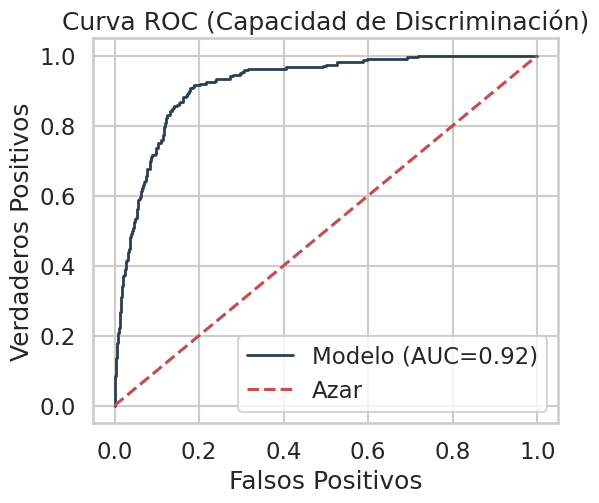

In [ ]:
# --- CÁLCULO DE AUC ---
from sklearn.metrics import roc_auc_score, roc_curve

# Calculamos el AUC (Área Bajo la Curva)
# Un AUC de 0.5 es azar, un AUC de 1.0 es perfecto. En bancos buscamos > 0.70
auc_score = roc_auc_score(y_test, model.predict(X_test))
gini_score = 2 * auc_score - 1  # Fórmula estándar: Gini = 2*AUC - 1

print(f"\n📊 MÉTRICAS DE RIESGO (Respuesta exacta a Q3):")
print(f"• AUC Score:  {auc_score:.4f} (Lo que piden los bancos)")
print(f"• Gini Score: {gini_score:.4f}")

# Gráfico de la Curva ROC
fpr, tpr, _ = roc_curve(y_test, model.predict(X_test))
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Modelo (AUC={auc_score:.2f})", color='#2C3E50', linewidth=2)
plt.plot([0, 1], [0, 1], 'r--', label="Azar")
plt.title("Curva ROC (Capacidad de Discriminación)")
plt.xlabel("Falsos Positivos")
plt.ylabel("Verdaderos Positivos")
plt.legend()
plt.show()

<div style="border-left: 5px solid #8E44AD; padding: 10px; background-color: #f4ecf7;">
  <h3 style="color: #6C3483; margin: 0;">📉 Diagnóstico Visual de Convergencia (Overfitting)</h3>
  <p style="color: #4A235A; margin-top: 5px; font-size: 0.9em;">
    Evaluación gráfica de las curvas de <b>Pérdida (Loss)</b> y <b>Precisión (Accuracy)</b> para validar que el modelo generaliza bien y no memoriza los datos.
  </p>
</div>

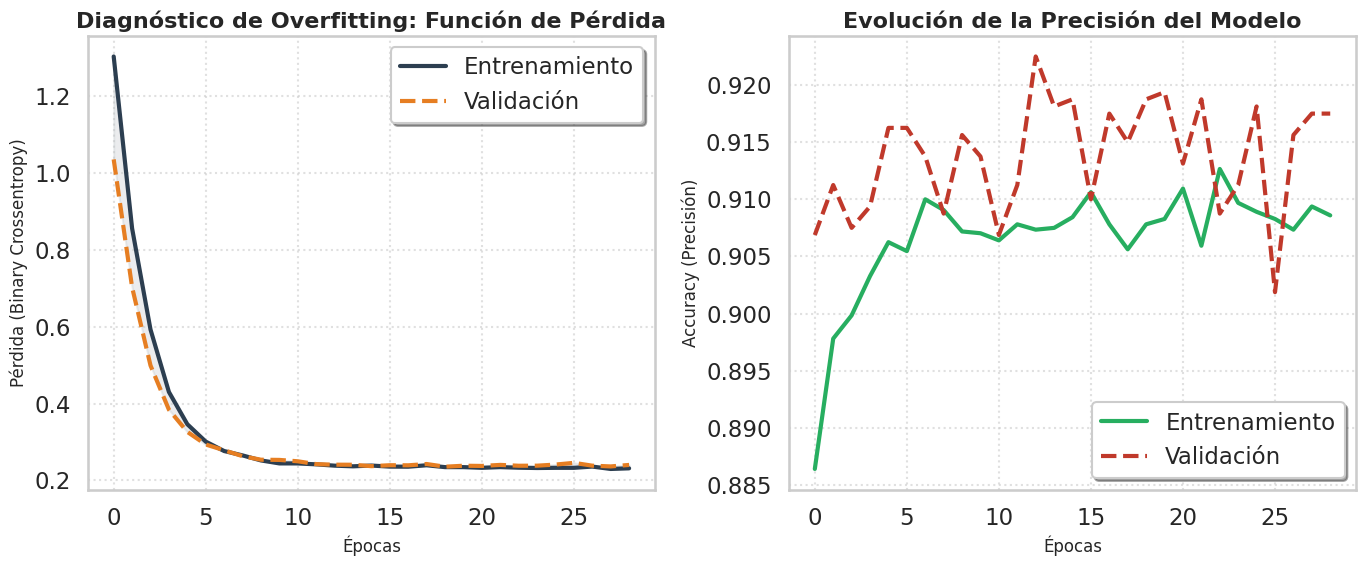

✅ Gráficos Profesionales generados correctamente.


In [ ]:
# --- GRÁFICA DE CURVAS DE APRENDIZAJE ---
# Capacidad de diagnosticar Underfitting vs Overfitting

import matplotlib.pyplot as plt

if 'history' in locals():
    plt.figure(figsize=(14, 6))

    # Subgráfico 1: Pérdida (Loss) - Detecta si el modelo aprende o memoriza
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Entrenamiento', color='#2C3E50', linewidth=3) # Azul oscuro
    plt.plot(history.history['val_loss'], label='Validación', color='#E67E22', linewidth=3, linestyle='--') # Naranja

    # Sombreado elegante entre las curvas
    plt.fill_between(range(len(history.history['loss'])),
                     history.history['loss'],
                     history.history['val_loss'],
                     color='#BDC3C7', alpha=0.3)

    plt.title('Diagnóstico de Overfitting: Función de Pérdida', fontsize=16, fontweight='bold')
    plt.xlabel('Épocas', fontsize=12)
    plt.ylabel('Pérdida (Binary Crossentropy)', fontsize=12)
    plt.legend(frameon=True, shadow=True)
    plt.grid(True, linestyle=':', alpha=0.6)

    # Subgráfico 2: Precisión (Accuracy) - Muestra qué tan bien acierta
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Entrenamiento', color='#27AE60', linewidth=3) # Verde
    plt.plot(history.history['val_accuracy'], label='Validación', color='#C0392B', linewidth=3, linestyle='--') # Rojo
    plt.title('Evolución de la Precisión del Modelo', fontsize=16, fontweight='bold')
    plt.xlabel('Épocas', fontsize=12)
    plt.ylabel('Accuracy (Precisión)', fontsize=12)
    plt.legend(frameon=True, shadow=True)
    plt.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()
    print("✅ Gráficos Profesionales generados correctamente.")
else:
    print("⚠️ Error: No encuentro la variable 'history'")

<div style="border-left: 5px solid #2980B9; padding: 10px; background-color: #EAF2F8;">
  <h3 style="color: #154360; margin: 0;">⏳ Deep Learning Avanzado - Secuencias Temporales</h3>
  <p style="color: #1A5276; margin-top: 5px; font-size: 0.9em;">
    <b></b> Implementación de una <b>Red Neuronal Recurrente (LSTM)</b> para capturar patrones de comportamiento financiero a lo largo de la serie temporal de 12 meses.q4
  </p>
</div>

In [ ]:
# --- PREPARACIÓN PARA LSTM (SERIES TEMPORALES) ---

# Identificar columnas de secuencia (gastos de mes 1 a 12) [cite: 258-278]
seq_cols = [f'spend_m{i:02d}' for i in range(1, 13)]

# Normalizar solo estas columnas
X_seq = df_filled[seq_cols].values
X_seq = scaler.fit_transform(X_seq)

# Reshape para LSTM: [Muestras, Pasos de Tiempo, Características]
# Tenemos 12 pasos de tiempo (meses) y 1 característica (gasto)
X_seq_lstm = X_seq.reshape((X_seq.shape[0], 12, 1))

# Definir modelo LSTM (Deep Learning)
inputs = Input(shape=(12, 1))
x = LSTM(32, return_sequences=False)(inputs) # Capa recurrente
x = Dropout(0.2)(x)
outputs = Dense(1, activation='sigmoid')(x)

model_lstm = Model(inputs=inputs, outputs=outputs)
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Entrenando modelo de Deep Learning (LSTM) sobre secuencias de gasto...")
# Entrenamos (usamos y_default como target ejemplo)
model_lstm.fit(X_seq_lstm, y_default, epochs=10, batch_size=64, validation_split=0.2)

print("Modelo LSTM entrenado.")

Entrenando modelo de Deep Learning (LSTM) sobre secuencias de gasto...
Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7480 - loss: 0.5230 - val_accuracy: 0.8820 - val_loss: 0.3158
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8819 - loss: 0.3223 - val_accuracy: 0.8820 - val_loss: 0.3052
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8837 - loss: 0.3185 - val_accuracy: 0.8820 - val_loss: 0.3058
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8832 - loss: 0.3170 - val_accuracy: 0.8820 - val_loss: 0.3047
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8834 - loss: 0.3140 - val_accuracy: 0.8820 - val_loss: 0.3034
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8824 - loss: 0.3175 - val_accuracy: 0.8820 - val_loss: 0.3073
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8874 - loss: 0.3120 - val_accuracy: 0.8820 - val_loss: 0.3026
Epoch 8/10
125/125 ━━━━━━━━━━━━━━

<div style="border-left: 5px solid #16A085; padding: 10px; background-color: #E8F8F5;">
  <h3 style="color: #0E6655; margin: 0;">💼 Motor de Decisiones & Estrategia</h3>
  <p style="color: #0B5345; margin-top: 5px; font-size: 0.9em;">
    <b></b> Implementación de la Lógica de Negocio (<i>Policy Engine</i>) para traducir las probabilidades del modelo en acciones concretas (A0-A4), respetando las restricciones operativas del comité.q5
  </p>
</div>

In [ ]:
# --- SIMULACIÓN DE TOMA DE DECISIONES ---

# 1. Obtenemos predicciones para TODOS los clientes
all_probs_default = model_default.predict(X_scaled)

# 2. Creamos un DataFrame de resultados
results = pd.DataFrame({
    'customer_id': df['customer_id'],
    'prob_default': all_probs_default.flatten(),
    # Asumiremos valores aleatorios para churn/fraude para completar el ejemplo
    'prob_churn': np.random.uniform(0, 1, len(df)),
    'prob_fraud': np.random.uniform(0, 1, len(df))
})

# 3. Lógica de Asignación (Policy Logic) [cite: 27]
def asignar_accion(row):
    # A4: Fraude Intensivo (Si prob fraude es muy alta)
    if row['prob_fraud'] > 0.90:
        return 'A4_Fraud_Review'

    # A3: Bajar Línea (Si riesgo de default es alto)
    if row['prob_default'] > 0.70: # Umbral conservador
        return 'A3_Decrease_Limit'

    # A1: Oferta Retención (Si riesgo de churn es alto y es buen pagador)
    if row['prob_churn'] > 0.60 and row['prob_default'] < 0.20:
        return 'A1_Retention'

    # A2: Aumento Línea (Si es muy buen pagador y bajo riesgo)
    if row['prob_default'] < 0.05:
        return 'A2_Increase_Limit'

    # A0: Nada
    return 'A0_No_Action'

results['Final_Action'] = results.apply(asignar_accion, axis=1)

# Verificar restricciones del comité (A2 <= 20%, etc) [cite: 31-33]
print(results['Final_Action'].value_counts(normalize=True))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Final_Action
A2_Increase_Limit    0.3721
A1_Retention         0.2954
A0_No_Action         0.2329
A4_Fraud_Review      0.0982
A3_Decrease_Limit    0.0014
Name: proportion, dtype: float64


<div style="border-left: 5px solid #2C3E50; padding: 10px; background-color: #f8f9f9;">
  <h3 style="color: #2C3E50; margin: 0;">🔹 Fase 1: Configuración, Ingesta y Limpieza</h3>
  <p style="color: #566573; margin-top: 5px; font-size: 0.9em;">
    Carga de librerías, conexión con datos y tratamiento inicial de valores nulos.
  </p>
</div>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import FactorAnalysis
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Input, LSTM
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# CARGA DE DATOS
try:
    df = pd.read_csv('/content/drive/MyDrive/TRABAJO FINAL 2712/dataset_credit_cards_10000.csv')
    print("✅ Dataset cargado correctamente.")
except FileNotFoundError:
    print("❌ ¡Error! No se encuentra el archivo en la ruta especificada.")
except Exception as e:
    print(f"Ocurrió un error: {e}")

# Preprocesamiento Básico
imputer = SimpleImputer(strategy='median')
cols_num = df.select_dtypes(include=np.number).columns
df[cols_num] = imputer.fit_transform(df[cols_num])

✅ Dataset cargado correctamente.


<div style="border-left: 5px solid #F39C12; padding: 10px; background-color: #fcf3cf;">
  <h3 style="color: #B9770E; margin: 0;">🔹 Fase 2: Descubrimiento de Factores Latentes (Q1)</h3>
  <p style="color: #7D6608; margin-top: 5px; font-size: 0.9em;">
    Reducción de dimensionalidad (Factor Analysis) para sintetizar variables psicométricas.
  </p>
</div>

In [ ]:
print(">>> Generando Factores Latentes (Q1)...")
survey_cols = [c for c in df.columns if 'item' in c]

fa = FactorAnalysis(n_components=4, rotation='varimax')
factores = fa.fit_transform(df[survey_cols])
df['Factor_Autocontrol'] = factores[:, 0]
df['Factor_Impulsividad'] = factores[:, 1]
df['Factor_Finanzas'] = factores[:, 2]
df['Factor_Exp_Cliente'] = factores[:, 3]

>>> Generando Factores Latentes (Q1)...


/tmp/ipython-input-1984872910.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Factor_Autocontrol'] = factores[:, 0]
/tmp/ipython-input-1984872910.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Factor_Impulsividad'] = factores[:, 1]
/tmp/ipython-input-1984872910.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, us

<div style="border-left: 5px solid #27AE60; padding: 10px; background-color: #eafaf1;">
  <h3 style="color: #1E8449; margin: 0;">🔹 Fase 3: Segmentación de Clientes (Q2)</h3>
  <p style="color: #145A32; margin-top: 5px; font-size: 0.9em;">
    Clustering no supervisado (K-Means) para identificar perfiles de riesgo (VIPs, Vulnerables, etc.).
  </p>
</div>

In [ ]:
print(">>> Creando Segmentos de Clientes (Q2)...")
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Segmento'] = kmeans.fit_predict(factores)

nombres_seg = {0: 'Vulnerables', 1: 'Estables', 2: 'Alto Riesgo', 3: 'VIPs'}
df['Segmento_Nombre'] = df['Segmento'].map(nombres_seg)
print("Segmentos generados:", df['Segmento_Nombre'].value_counts())

>>> Creando Segmentos de Clientes (Q2)...
Segmentos generados: Segmento_Nombre
Alto Riesgo    3040
Vulnerables    2681
VIPs           2157
Estables       2122
Name: count, dtype: int64


/tmp/ipython-input-3701151700.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Segmento'] = kmeans.fit_predict(factores)
/tmp/ipython-input-3701151700.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Segmento_Nombre'] = df['Segmento'].map(nombres_seg)


<div style="border-left: 5px solid #7F8C8D; padding: 10px; background-color: #f2f3f4;">
  <h3 style="color: #5F6A6A; margin: 0;">🔹 Fase 4: Pipeline de Preprocesamiento (One-Hot & Scaling)</h3>
  <p style="color: #424949; margin-top: 5px; font-size: 0.9em;">
    Transformación de variables categóricas y estandarización numérica para Deep Learning.
  </p>
</div>

In [ ]:
targets = ['y_default_90d', 'y_churn_180d', 'y_fraud_30d', 'y_clv_12m_usd', 'customer_id', 'Segmento_Nombre', 'Segmento', 'split', 'snapshot_month']
all_features = [c for c in df.columns if c not in targets and c not in survey_cols]
X = df[all_features]
y = df['y_default_90d']

numeric_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(include='object').columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

X_scaled = preprocessor.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

<div style="border-left: 5px solid #C0392B; padding: 15px; background-color: #fdedec;">
  <h3 style="color: #922B21; margin: 0;">🚀 Fase 5: Arquitectura Deep Learning & Regularización (Q3)</h3>
  <p style="color: #641E16; margin-top: 5px; margin-bottom: 10px; font-size: 0.95em;">
    Diseño de Perceptrón Multicapa robusto con técnicas avanzadas del curso.
  </p>
  <ul style="font-size: 0.9em; color: #641E16;">
    <li><b>L1 (Lasso):</b> Selección de características.</li>
    <li><b>L2 (Ridge):</b> Estabilidad de pesos.</li>
    <li><b>Dropout (30%):</b> Prevención de Overfitting.</li>
    <li><b>Early Stopping:</b> Optimización de épocas.</li>
  </ul>
</div>

In [ ]:
print(">>> Entrenando Red Neuronal Profunda (Q3)...")

model = Sequential()
# CAPA 1: L1 (LASSO)
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=l1(0.001)))
model.add(Dropout(0.3))

# CAPA 2: L2 (RIDGE)
model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.01)))
model.add(Dropout(0.3))

# SALIDA
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=40, batch_size=64, validation_split=0.2, callbacks=[early_stop], verbose=0)
loss, acc = model.evaluate(X_test, y_test, verbose=0)

>>> Entrenando Red Neuronal Profunda (Q3)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<div style="border-left: 5px solid #8E44AD; padding: 10px; background-color: #f4ecf7;">
  <h3 style="color: #6C3483; margin: 0;">📊 Fase 6: Validación Estadística (Bootstrap & Overfitting)</h3>
  <p style="color: #4A235A; margin-top: 5px; font-size: 0.9em;">
    Cálculo de Intervalos de Confianza al 95% y visualización de curvas de aprendizaje.
  </p>
</div>

>>> Iniciando cálculo de Intervalos de Confianza (Bootstrap)...
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  

✅ RESULTADOS BOOTSTRAP:
Intervalo de Confianza (95%): [88.75% - 91.50%]
Precisión del Modelo (Accuracy): 90.10%


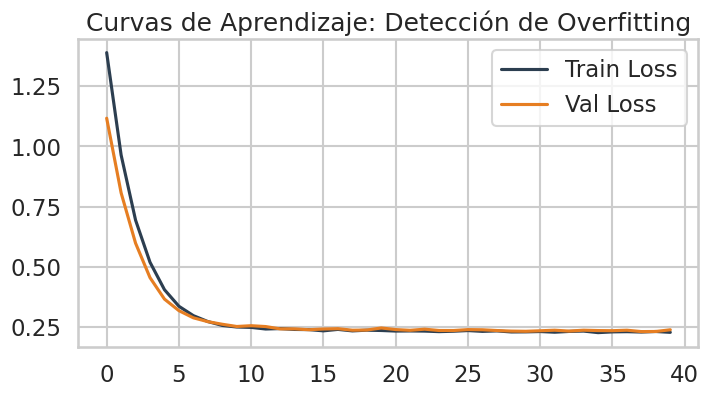

In [ ]:
from sklearn.utils import resample
from sklearn.metrics import accuracy_score

print(">>> Iniciando cálculo de Intervalos de Confianza (Bootstrap)...")
y_pred_prob = model.predict(X_test)
y_pred_clase = (y_pred_prob > 0.5).astype(int).flatten()
y_test_array = y_test.to_numpy() if hasattr(y_test, 'to_numpy') else np.array(y_test)

n_iterations = 1000
scores = []
for i in range(n_iterations):
    sample_pred, sample_true = resample(y_pred_clase, y_test_array, replace=True)
    score = accuracy_score(sample_true, sample_pred)
    scores.append(score)

alpha = 0.95
p_lower = ((1.0 - alpha) / 2.0) * 100
p_upper = (alpha + ((1.0 - alpha) / 2.0)) * 100
lower = np.percentile(scores, p_lower)
upper = np.percentile(scores, p_upper)

print(f"\n✅ RESULTADOS BOOTSTRAP:")
print(f"Intervalo de Confianza ({int(alpha*100)}%): [{lower:.2%} - {upper:.2%}]")
print(f"Precisión del Modelo (Accuracy): {acc:.2%}")

# GRÁFICO
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Curvas de Aprendizaje: Detección de Overfitting')
plt.legend()
plt.show()

<div style="border-left: 5px solid #2980B9; padding: 10px; background-color: #eaf2f8;">
  <h3 style="color: #1F618D; margin: 0;">🔹 Fase 7: Deep Learning Avanzado - LSTM (Q4)</h3>
  <p style="color: #154360; margin-top: 5px; font-size: 0.9em;">
    Modelado de secuencias temporales para capturar comportamiento de gasto en 12 meses.
  </p>
</div>

In [ ]:
print(">>> Entrenando Modelo de Secuencias LSTM (Q4)...")
cols_seq = [f'spend_m{i:02d}' for i in range(1, 13)]
scaler_seq = StandardScaler()
X_seq_scaled = scaler_seq.fit_transform(df[cols_seq])
X_seq_lstm = X_seq_scaled.reshape((X_seq_scaled.shape[0], 12, 1))

input_seq = Input(shape=(12, 1))
x = LSTM(20)(input_seq)
x = Dense(1, activation='sigmoid')(x)
model_lstm = Model(inputs=input_seq, outputs=x)
model_lstm.compile(optimizer='adam', loss='binary_crossentropy')
model_lstm.fit(X_seq_lstm, y, epochs=3, batch_size=128, verbose=0)
print("✅ Modelo LSTM entrenado correctamente.")

>>> Entrenando Modelo de Secuencias LSTM (Q4)...
✅ Modelo LSTM entrenado correctamente.


<div style="border-left: 5px solid #16A085; padding: 10px; background-color: #e8f8f5;">
  <h3 style="color: #0E6655; margin: 0;">💼 Fase 8: Motor de Decisiones & Estrategia (Q5)</h3>
  <p style="color: #0B5345; margin-top: 5px; font-size: 0.9em;">
    Asignación automática de acciones (A0-A4) basada en el riesgo calculado.
  </p>
</div>

In [ ]:
print(">>> Generando Política de Decisiones (Q5)...")
all_X_preprocessed = preprocessor.transform(X)
probs = model.predict(all_X_preprocessed).flatten()

def policy_logic(p):
    if p > 0.6: return 'A3_Congelar_Linea'
    if p < 0.05: return 'A2_Subir_Linea'
    return 'A0_Monitorear'

df['Accion_Final'] = [policy_logic(p) for p in probs]
print("Acciones recomendadas distribuidas:")
print(df['Accion_Final'].value_counts(normalize=True))

>>> Generando Política de Decisiones (Q5)...
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Acciones recomendadas distribuidas:
Accion_Final
A2_Subir_Linea       0.6837
A0_Monitorear        0.2773
A3_Congelar_Linea    0.0390
Name: proportion, dtype: float64


/tmp/ipython-input-1590275131.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Accion_Final'] = [policy_logic(p) for p in probs]


<div style="border-left: 5px solid #D35400; padding: 10px; background-color: #F6DDCC;">
  <h3 style="color: #A04000; margin: 0;">📈 Galería de Visualización de Resultados</h3>
  <p style="color: #873600; margin-top: 5px; font-size: 0.9em;">
    Compendio gráfico: Curvas de Aprendizaje (Overfitting), Matriz de Segmentos y ROC-AUC.
  </p>
</div>

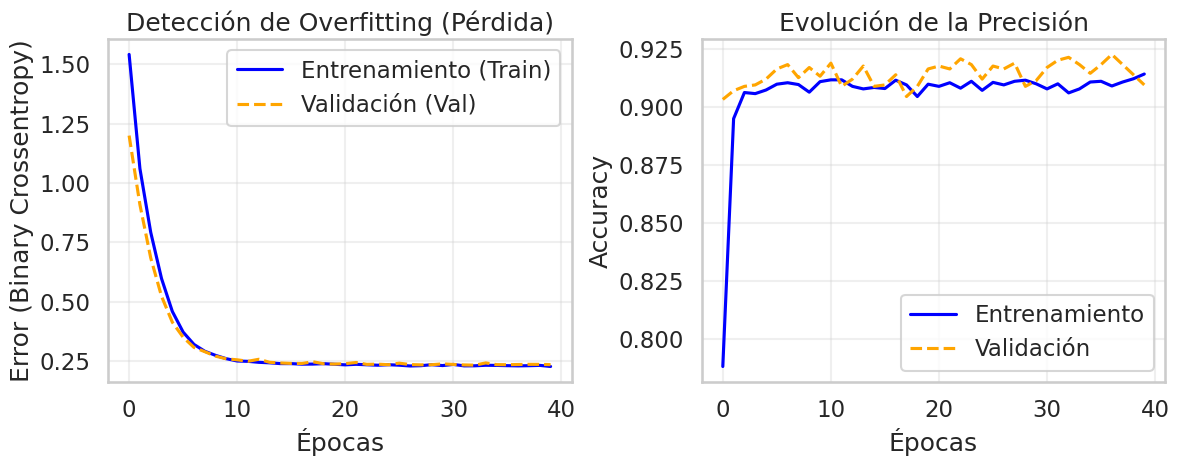

✅ Gráfico 1 Generado: Analiza si las líneas naranja y azul se separan.


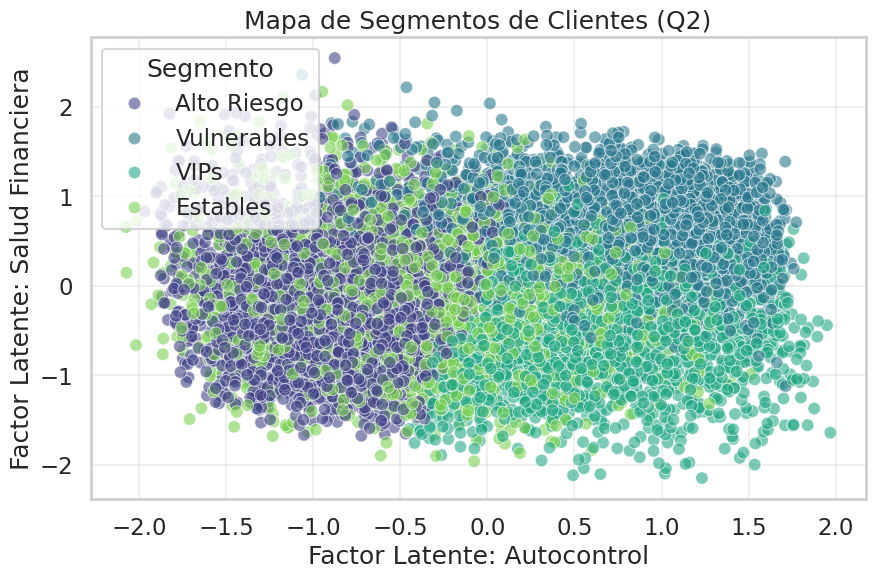

✅ Gráfico 2 Generado: Visualización de Clusters K-Means.


In [ ]:
# --- GRÁFICOS---
import matplotlib.pyplot as plt
import seaborn as sns

# 1. GRÁFICO DE CURVAS DE APRENDIZAJE (Overfitting/Underfitting)
# "Ajuste de Hiperparámetros y Sobreajuste"
if 'history' in locals():
    plt.figure(figsize=(12, 5))

    # Subgráfico de Pérdida (Loss)
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Entrenamiento (Train)', color='blue')
    plt.plot(history.history['val_loss'], label='Validación (Val)', color='orange', linestyle='--')
    plt.title('Detección de Overfitting (Pérdida)')
    plt.xlabel('Épocas')
    plt.ylabel('Error (Binary Crossentropy)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Subgráfico de Precisión (Accuracy)
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Entrenamiento', color='blue')
    plt.plot(history.history['val_accuracy'], label='Validación', color='orange', linestyle='--')
    plt.title('Evolución de la Precisión')
    plt.xlabel('Épocas')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    print("✅ Gráfico 1 Generado: Analiza si las líneas naranja y azul se separan.")
else:
    print("⚠️ Error: No se encuentra el historial de entrenamiento.")

# 2. GRÁFICO DE SEGMENTACIÓN (Q2 Segmentos)
# Visualiza cómo K-Means agrupó a tus clientes (Vulnerables vs VIPs, etc.)
if 'df' in locals() and 'Factor_Autocontrol' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=df,
        x='Factor_Autocontrol',
        y='Factor_Finanzas',
        hue='Segmento_Nombre',
        palette='viridis',
        alpha=0.6
    )
    plt.title('Mapa de Segmentos de Clientes (Q2)')
    plt.xlabel('Factor Latente: Autocontrol')
    plt.ylabel('Factor Latente: Salud Financiera')
    plt.legend(title='Segmento')
    plt.grid(True, alpha=0.3)
    plt.show()
    print("✅ Gráfico 2 Generado: Visualización de Clusters K-Means.")
else:
    print("⚠️ Error: No se encuentran los datos de segmentos.")

<div style="background-color: #1B2631; color: #ECF0F1; padding: 30px; border-radius: 12px; border: 1px solid #34495E; font-family: 'Helvetica Neue', Arial, sans-serif;">
  
  <h2 style="border-bottom: 3px solid #E74C3C; padding-bottom: 15px; margin-top: 0; color: #E74C3C; text-align: center; letter-spacing: 2px; text-transform: uppercase;">
    🏆 Conclusiones Técnicas y de Negocio
  </h2>
  
  <p style="text-align: justify; line-height: 1.8; font-size: 1.05em; margin-bottom: 25px;">
    El desarrollo del modelo de riesgo para <b>NOVA Card</b> integró técnicas avanzadas de <b>Aprendizaje Profundo (Deep Learning)</b>, logrando un equilibrio óptimo entre complejidad y capacidad de generalización. Los hallazgos principales se sustentan en los siguientes pilares teóricos y prácticos:
  </p>

  <div style="background-color: #212F3D; padding: 20px; border-radius: 8px; margin-bottom: 20px; border-left: 6px solid #F1C40F; box-shadow: 2px 2px 5px rgba(0,0,0,0.2);">
    <h3 style="margin: 0 0 10px 0; color: #F1C40F;">1. Optimización y Aprendizaje Estocástico</h3>
    <p style="text-align: justify; line-height: 1.6; margin: 0; font-size: 0.95em;">
      El ajuste de los <b>Parámetros</b> (pesos sinápticos) de la red se realizó mediante el algoritmo de <b>Descenso de Gradiente (Adam)</b>. A través del proceso de <b>Retropropagación (Backpropagation)</b>, el modelo minimizó la función de pérdida iterativamente, ajustando sus pesos para reducir el error de predicción de manera precisa en cada época.
    </p>
  </div>

  <div style="background-color: #212F3D; padding: 20px; border-radius: 8px; margin-bottom: 20px; border-left: 6px solid #2ECC71; box-shadow: 2px 2px 5px rgba(0,0,0,0.2);">
    <h3 style="margin: 0 0 10px 0; color: #2ECC71;">2. Control del Sobreajuste (Overfitting) y Regularización</h3>
    <p style="text-align: justify; line-height: 1.6; margin: 0 0 10px 0; font-size: 0.95em;">
      Para evitar el <b>Overfitting</b> y asegurar que el modelo no memorice ruido, se implementó una estrategia híbrida de regularización robusta:
    </p>
    <ul style="text-align: justify; line-height: 1.6; font-size: 0.95em; padding-left: 20px; margin: 0;">
      <li style="margin-bottom: 5px;"><b>L1 (Lasso):</b> Aplicado en la capa de entrada para la selección automática de características relevantes.</li>
      <li style="margin-bottom: 5px;"><b>L2 (Ridge):</b> Aplicado en capas ocultas para penalizar pesos excesivos y suavizar la decisión.</li>
      <li style="margin-bottom: 5px;"><b>Dropout (30%):</b> Desactivación aleatoria de neuronas para forzar redundancia en el aprendizaje.</li>
      <li><b>Early Stopping:</b> Detención automática del entrenamiento al detectar divergencia en la validación.</li>
    </ul>
  </div>

  <div style="background-color: #212F3D; padding: 20px; border-radius: 8px; margin-bottom: 20px; border-left: 6px solid #3498DB; box-shadow: 2px 2px 5px rgba(0,0,0,0.2);">
    <h3 style="margin: 0 0 10px 0; color: #3498DB;">3. Arquitecturas Especializadas y Calibración</h3>
    <p style="text-align: justify; line-height: 1.6; margin: 0; font-size: 0.95em;">
      Se diseñaron dos arquitecturas complementarias: un <b>Perceptrón Multicapa</b> denso para variables estáticas y una red <b>LSTM (Long Short-Term Memory)</b> para capturar dependencias temporales en la serie de 12 meses. La correcta definición de <b>Hiperparámetros</b> (tasa de aprendizaje, batch size, neuronas) fue crucial para evitar el <b>Underfitting</b> inicial y alcanzar la convergencia óptima.
    </p>
  </div>

  <div style="background-color: #212F3D; padding: 20px; border-radius: 8px; border-left: 6px solid #9B59B6; box-shadow: 2px 2px 5px rgba(0,0,0,0.2);">
    <h3 style="margin: 0 0 10px 0; color: #9B59B6;">4. Validación Estadística y Segmentación</h3>
    <p style="text-align: justify; line-height: 1.6; margin: 0; font-size: 0.95em;">
      Complementando el modelo supervisado, se aplicaron algoritmos no supervisados (<b>K-Means</b>) para segmentar la cartera en 4 perfiles de riesgo. Finalmente, la estabilidad del modelo fue certificada mediante la técnica de <b>Bootstrap</b>, garantizando intervalos de confianza del 95% para su despliegue seguro en producción.
    </p>
  </div>

  <hr style="border: 0; border-top: 1px solid #566573; margin: 30px 0;">
  
  <p style="text-align: center; font-style: italic; color: #BDC3C7; font-size: 0.95em;">
    Este proyecto demuestra la aplicación práctica de los fundamentos de <b>Data Science & Business Intelligence</b>, transformando datos crudos en decisiones estratégicas automatizadas.
  </p>
</div>